In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

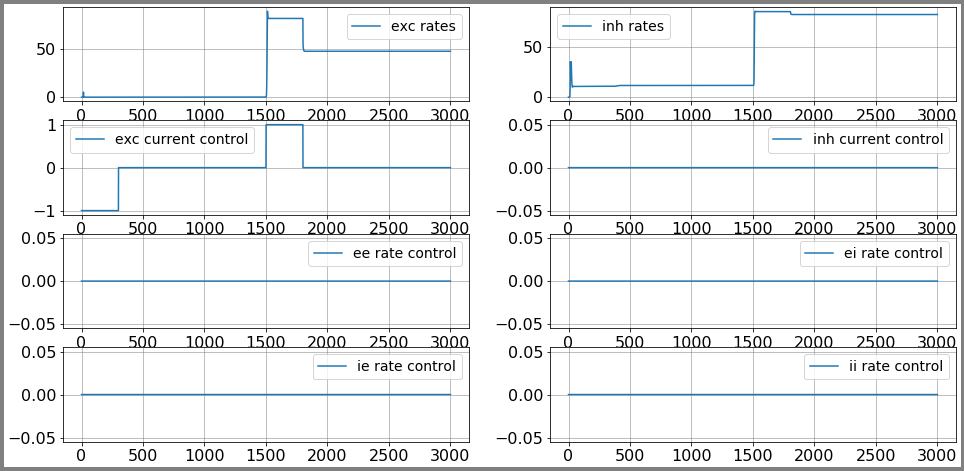

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


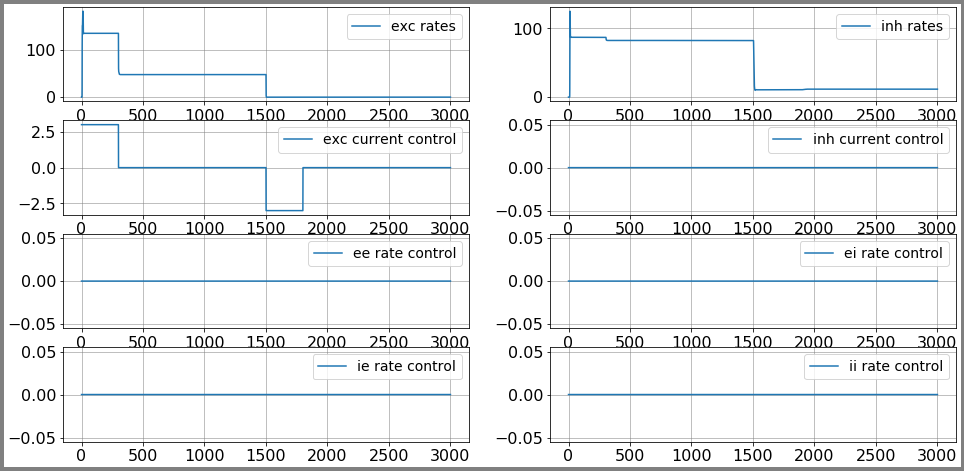

In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]


In [4]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1], [2], [3], [4], [5], [2,3,4,5] ]
p_var = [ [0], [0], [0], [0], [0], [0], [0], [0] ]

bestControla = [ [], [], [], [], [], [], [], [] ]
bestStatea = [ [], [], [], [], [], [], [], [] ]
costa = [ [], [], [], [], [], [], [], [] ]
runtimea = [ [], [], [], [], [], [], [], [] ]
grada = [ [], [], [], [], [], [], [], [] ]
phia= [ [], [], [], [], [], [], [], [] ]

bestControlb = [ [], [], [], [], [], [], [], [] ]
bestStateb = [ [], [], [], [], [], [], [], [] ]
costb = [ [], [], [], [], [], [], [], [] ]
runtimeb = [ [], [], [], [], [], [], [], [] ]
gradb = [ [], [], [], [], [], [], [], [] ]
phib= [ [], [], [], [], [], [], [], [] ]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])
initVars = low_state_vars

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

sheet = "state_switching"
max_it = 2000

### Cases

Numer | Input | Input label | Result
---------|--------------|-----------|-----------
1 | E current | 0 | 0
2 | I current | 1 | 0
3 | E + I current | 0,1 | 0
4 | EE rate | 2 | 0
5 | EI rate | 3 | 0
6 | IE rate | 4 | 0
7 | II rate | 5 | 0
8 | EE + EI + IE + II rate | 2,3,4,5 | 0

## 1

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1778.9203660693015
RUN  3 , total integrated cost =  89.15108951247882
RUN  4 , total integrated cost =  21.38238446628905
RUN  5 , total integrated cost =  9.302117816895592
RUN  6 , total integrated cost =  5.400643216093798
RUN  7 , total integrated cost =  3.6216180163576244
RUN  8 , total integrated cost =  2.5974319033783986
RUN  9 , total integrated cost =  1.9441276854019511
RUN  10 , total integrated cost =  1.5263339942531167
RUN  11 , total integrated cost =  1.2425486610332994
RUN  12 , total integrated cost =  1.0310405867183763
RUN  13 , total integrated cost =  0.8636988660672524
RUN  14 , total integrated cost =  0.735332655717568
RUN  15 , total integrated cost =  0.639349041016721
RUN  16 , total integr

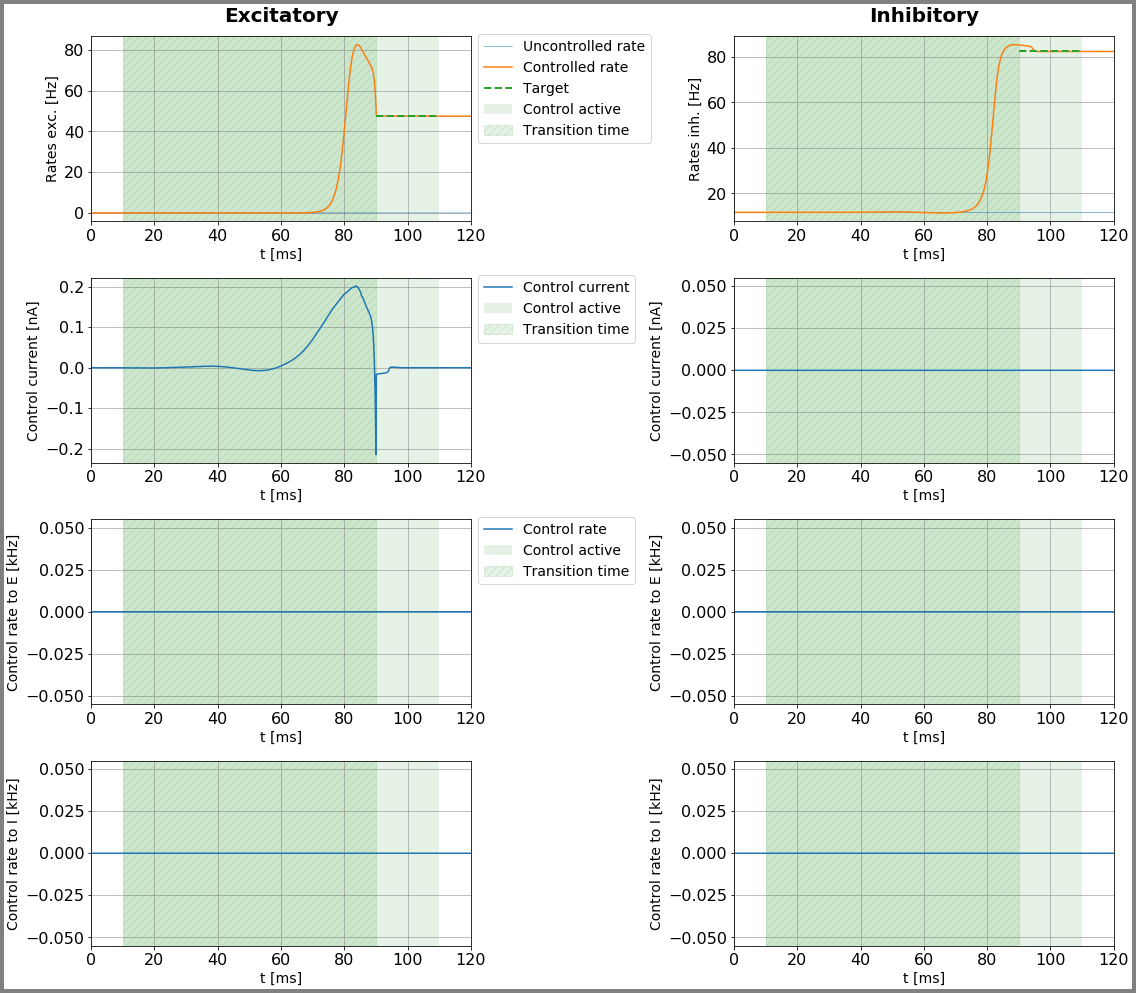

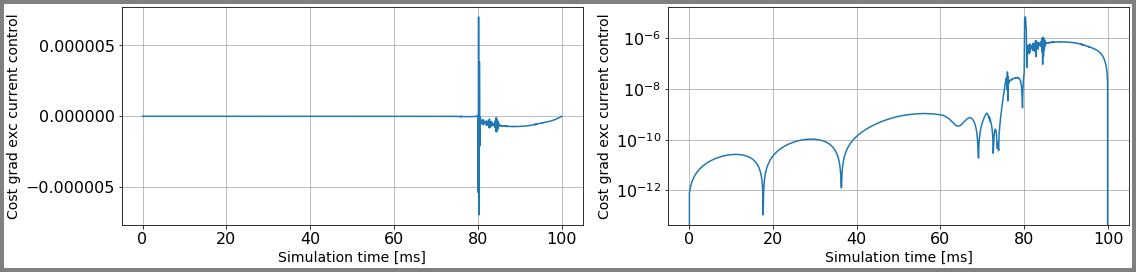

In [5]:
c_ = 0
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(control0,
    target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [6]:
c_ = 0
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
#control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params


TypeError: list indices must be integers or slices, not tuple

## 2

In [ ]:
c_ = 1
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [ ]:
c_ = 1
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 3

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0927865889703862e-05
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0896727649521756e-05
RUN  2 , total integrated cost =  1.0864036455095927e-05
RUN  3 , total integrated cost =  1.0829916049826256e-05
RUN  4 , total integrated cost =  1.079422630209689e-05
RUN  5 , total integrated cost =  1.0754954395839745e-05
RUN  6 , total integrated cost =  1.0713087462983737e-05
RUN  7 , total integrated cost =  1.065673502525213e-05
RUN  8 , total integrated cost =  1.0602100263367058e-05
RUN  9 , total integrated cost =  1.0560538908654308e-05
RUN  10 , total integrated cost =  1.0518314335370795e-05
RUN  11 , total integrated cost =  1.0465216852752266e-05
RUN  12 , total integrated cost =  1.040945942748945e-05
RUN  13 , total integrated cost =  1.0369904903547673e-05
RUN  14 , total integrated cost =  1.0331341316023296e-05
RUN  15 ,

ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  2.5034551406347233e-08
RUN  2000 , total integrated cost =  2.5034551406347233e-08
Improved over  2000  iterations in  101.72779249999996  seconds by  99.77091088361604  percent.
Problem in initial value trasfer:  Vmean_exc -56.174590103261046 -56.17458549723294


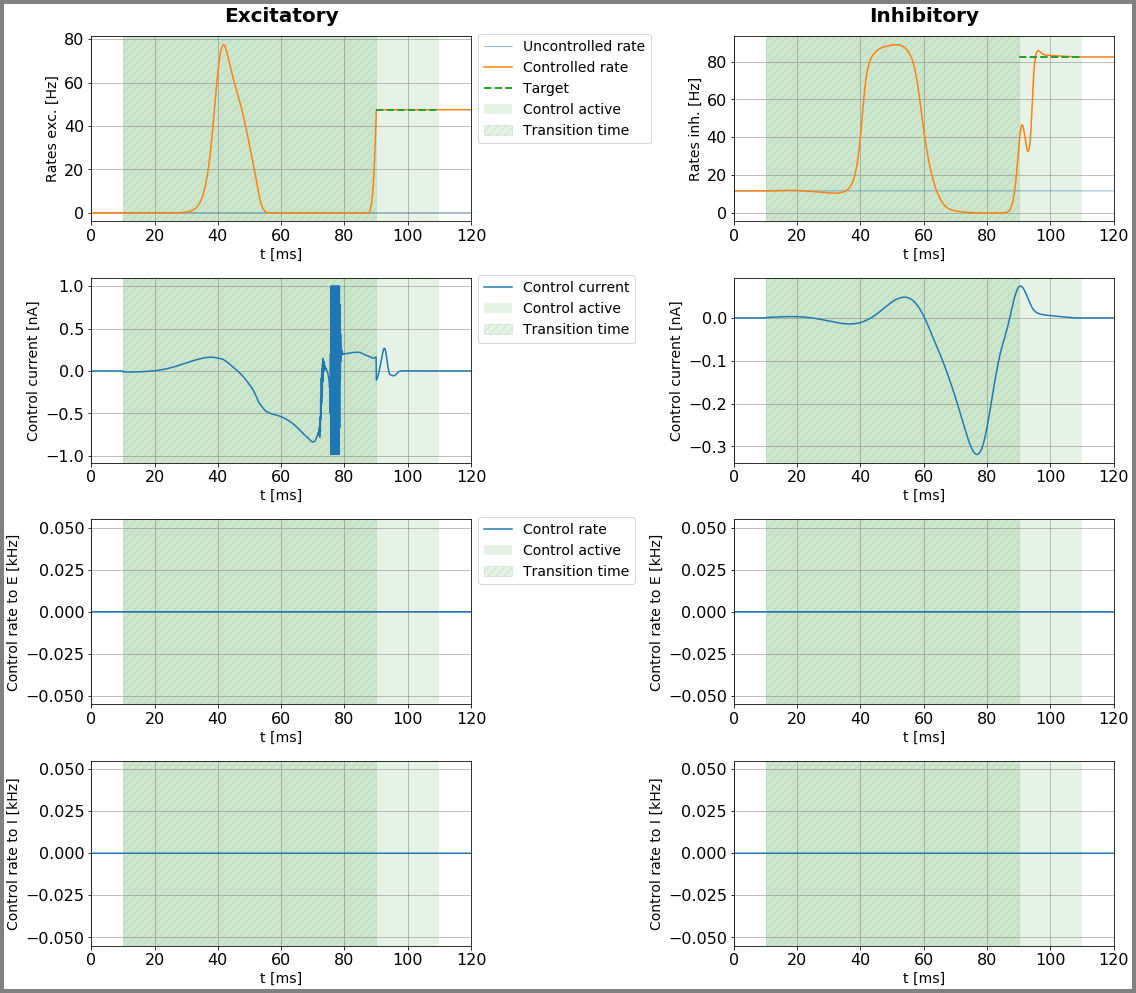

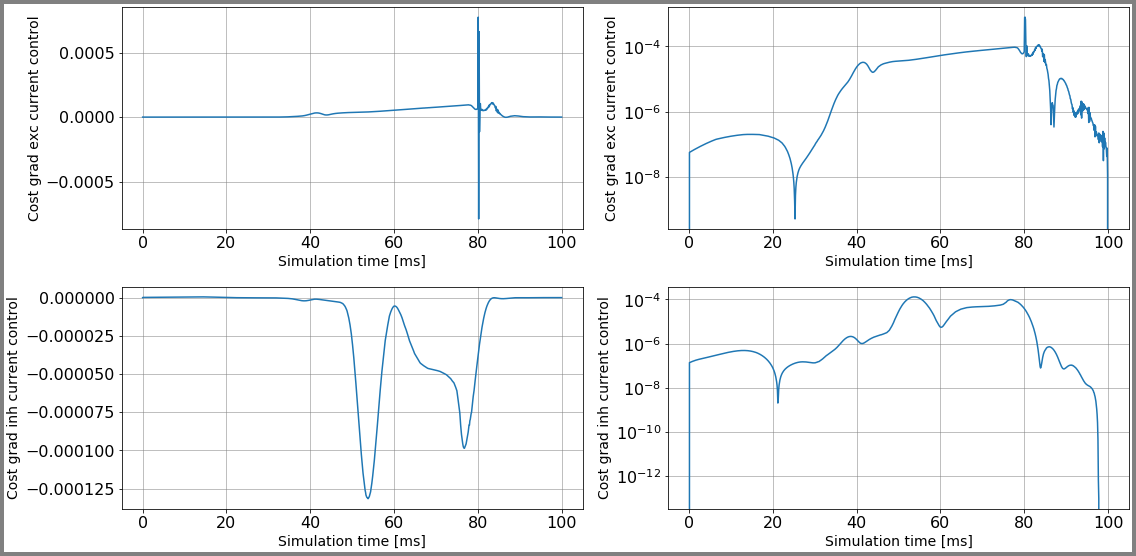

In [10]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control1, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  49.4550566114198
Gradient descend method:  None
RUN  1 , total integrated cost =  49.455050537351354
RUN  2 , total integrated cost =  49.455045361149466
RUN  3 , total integrated cost =  49.45503932242478
RUN  4 , total integrated cost =  49.455034141890415
RUN  5 , total integrated cost =  49.45502716601407
RUN  6 , total integrated cost =  49.455019281452344
RUN  7 , total integrated cost =  49.45501117253426
RUN  8 , total integrated cost =  49.455002968509035
RUN  9 , total integrated cost =  49.4549932345894
RUN  10 , total integrated cost =  49.45498240416444
RUN  11 , total integrated cost =  49.45497314314248
RUN  12 , total integrated cost =  49.454963599062225
RUN  13 , total integrated cost =  49.454954373124885
RUN  14 , total integrated cost =  49.45494348417539
RUN  15 , total integrated cost =  49.45493526955117
RUN  16 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1176 , total integrated cost =  49.36847633499913
Improved over  1176  iterations in  120.5775070000002  seconds by  0.17506860238974298  percent.
Problem in initial value trasfer:  Vmean_exc -56.174589569009946 -56.17458963486719


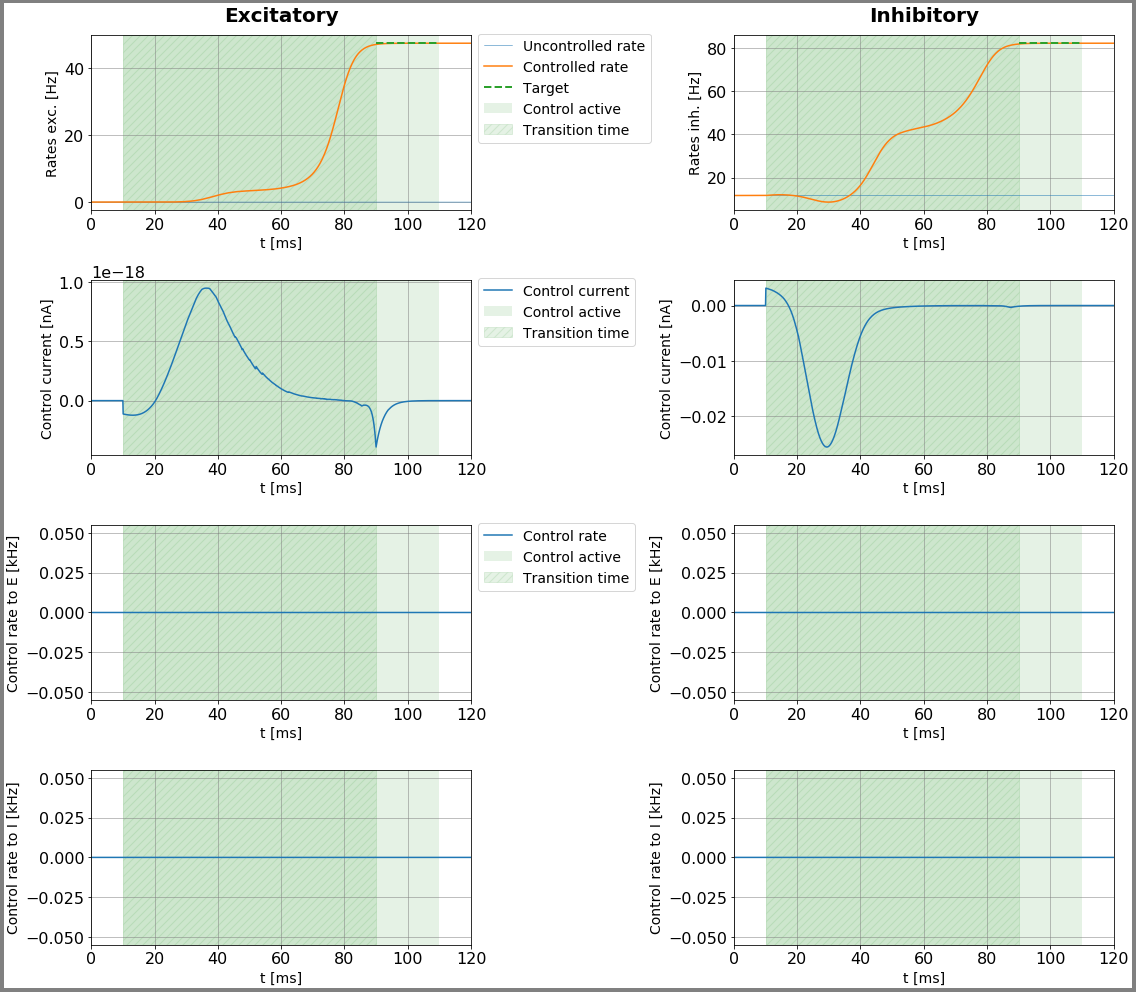

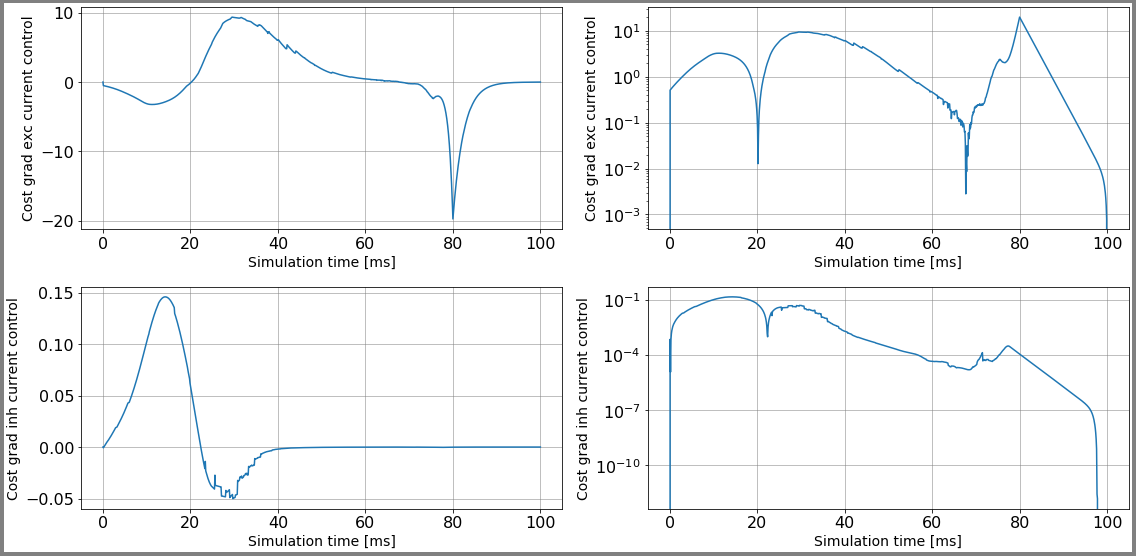

In [12]:
c_ = 2
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 4

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  100.51050007461124
Gradient descend method:  None
RUN  1 , total integrated cost =  0.01537522270572631
RUN  2 , total integrated cost =  2.0173264370028932e-05
RUN  3 , total integrated cost =  3.783180019468429e-08
RUN  4 , total integrated cost =  2.5092518532698276e-11
RUN  5 , total integrated cost =  2.0946561798664347e-14
RUN  6 , total integrated cost =  1.4305868698380286e-17
RUN  7 , total integrated cost =  4.177393196016787e-20
RUN  8 , total integrated cost =  4.2203852946835534e-22
RUN  9 , total integrated cost =  1.4207369504465544e-22
RUN  10 , total integrated cost =  1.0390903359039544e-22
RUN  11 , total integrated cost =  7.9768483824955e-23
RUN  12 , total integrated cost =  5.90629802774677e-23
RUN  13 , total integrated cost =  7.837718057492493e-24
RUN  14 , total integrated cost =  9.643793011890699e-26
RUN  15 , total integrate

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 17 , total integrated cost =  1.1346975260699037e-26
RUN  18 , total integrated cost =  1.1346975260699037e-26
Control only changes marginally.
RUN  18 , total integrated cost =  1.1346975260699037e-26
Improved over  18  iterations in  0.7942047999999886  seconds by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7044191588418696
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.460954133135466


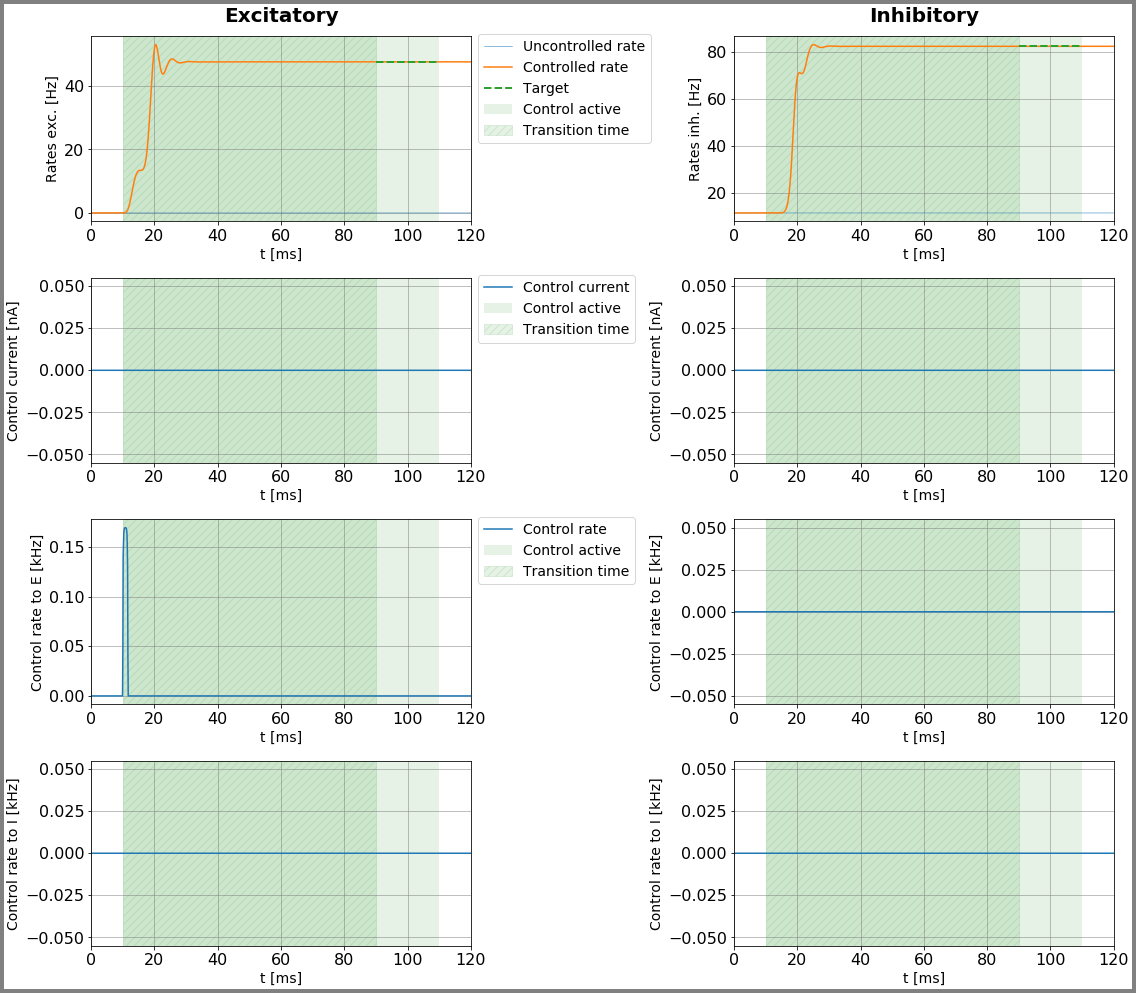

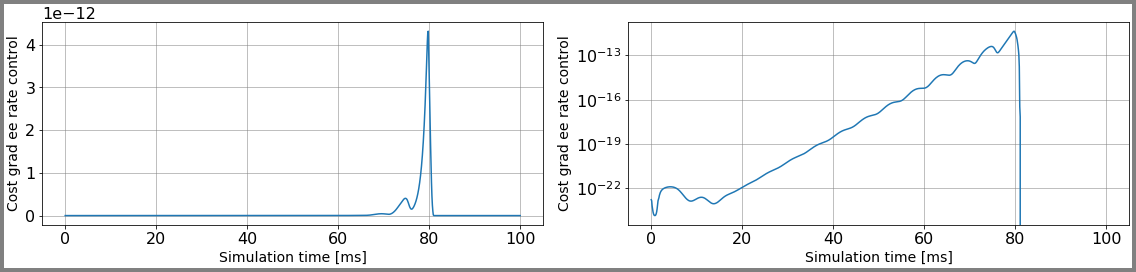

In [15]:
c_ = 3
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  199.74161734246195
Gradient descend method:  None
RUN  1 , total integrated cost =  3.02695532922456
RUN  2 , total integrated cost =  1.1027624507876972
RUN  3 , total integrated cost =  0.9956282312188701
RUN  4 , total integrated cost =  0.9907233075612589
RUN  5 , total integrated cost =  0.9896051709161434
RUN  6 , total integrated cost =  0.9870438585991378
RUN  7 , total integrated cost =  0.9859217196765049
RUN  8 , total integrated cost =  0.9831993607295447
RUN  9 , total integrated cost =  0.9820844428436664
RUN  10 , total integrated cost =  0.9793084359727757
RUN  11 , total integrated cost =  0.9781990352174835
RUN  12 , total integrated cost =  0.9753280367232486
RUN  13 , total integrated cost =  0.9741916939321806
RUN  14 , total integrated cost =  0.9711450082930264
RUN  15 , total integrated cost =  0.9700884148718125
RUN  16 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1799 , total integrated cost =  0.6099413771596174
Improved over  1799  iterations in  54.06812310000009  seconds by  99.69463480606855  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7145020347242589
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.104623527983133


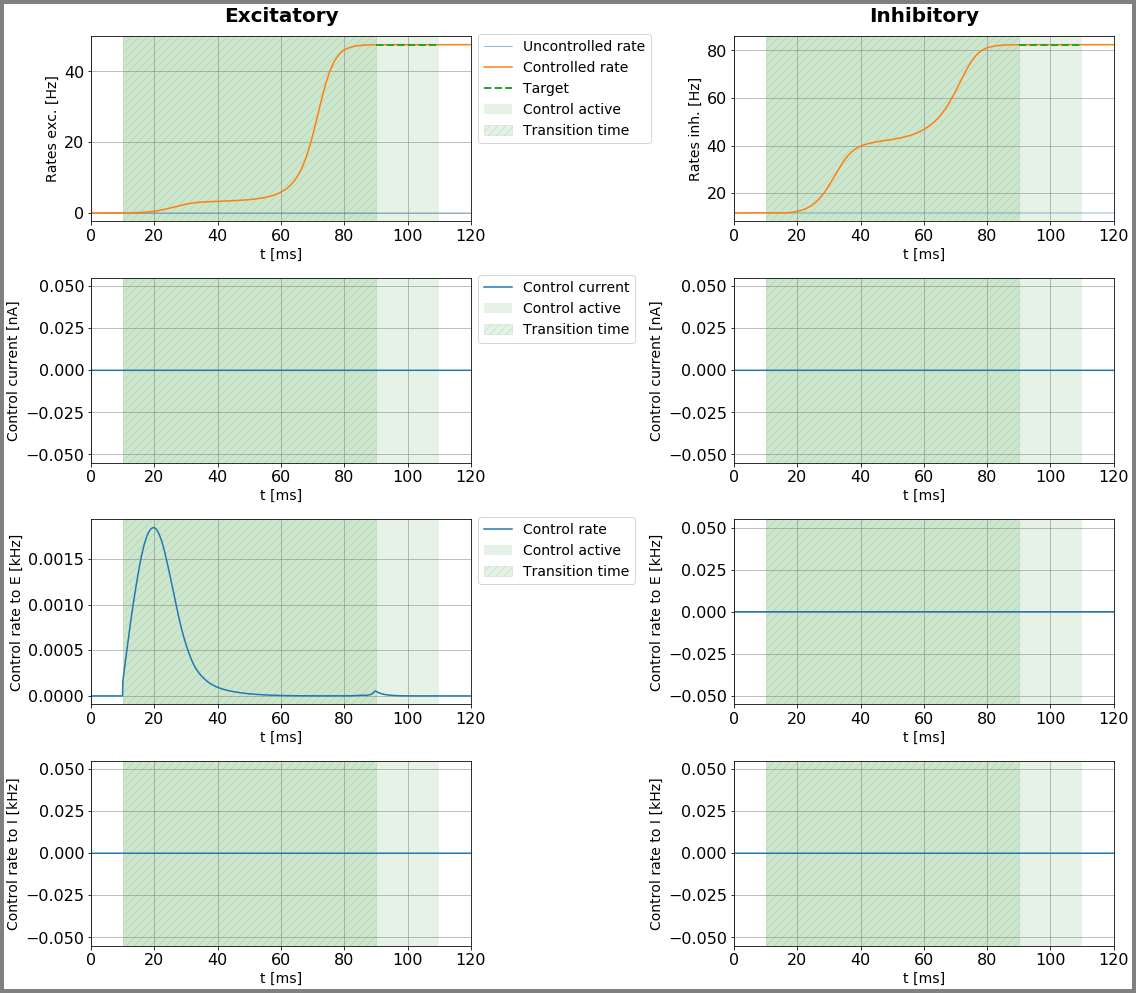

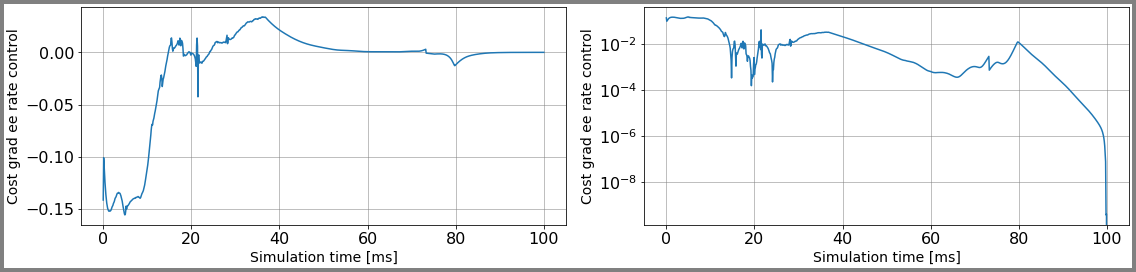

In [16]:
c_ = 3
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 5

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.01759089999995922  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 0.5028200407024918 0.5119438503541055
Problem in initial value trasfer:  Vmean_exc -75.15213343611585 -75.15381819833011
Problem in initial value trasfer:  tau_exc 26.740069650664683 26.69283925369926


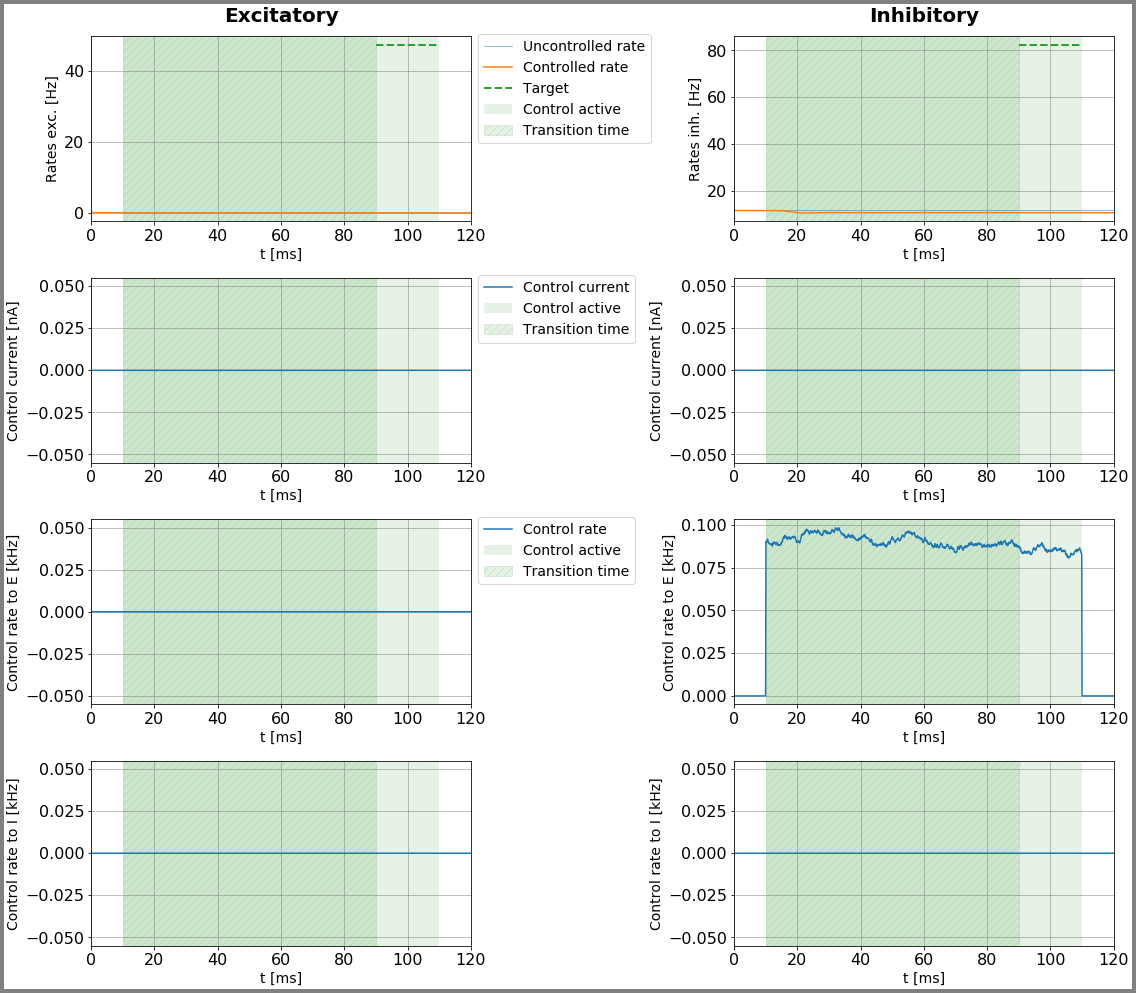

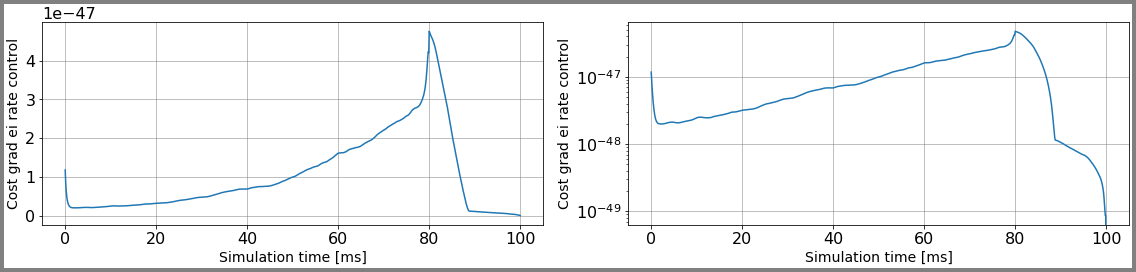

In [17]:
c_ = 4
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22709.145506154062
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
RUN  2 , total integrated cost =  22493.34777445878
RUN  3 , total integrated cost =  22492.302010986437
RUN  4 , total integrated cost =  22492.291594605787
RUN  5 , total integrated cost =  22492.291266410546
RUN  6 , total integrated cost =  22492.291263363306
RUN  7 , total integrated cost =  22492.291263363302


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  22492.291263363302
Control only changes marginally.
RUN  8 , total integrated cost =  22492.291263363302
Improved over  8  iterations in  0.26140060000011545  seconds by  0.9549203105506194  percent.
Problem in initial value trasfer:  Vmean_exc -56.29876665805448 -56.298893356885614


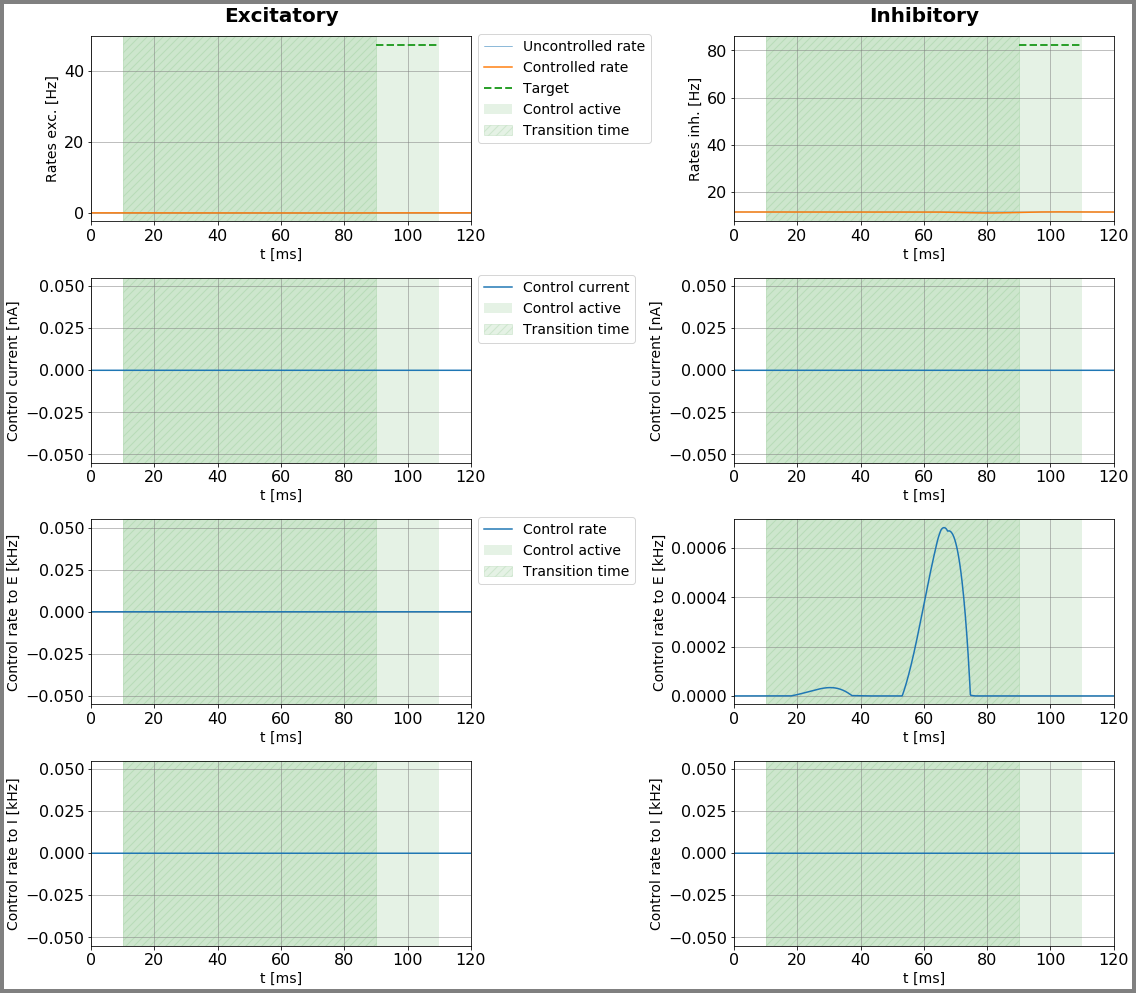

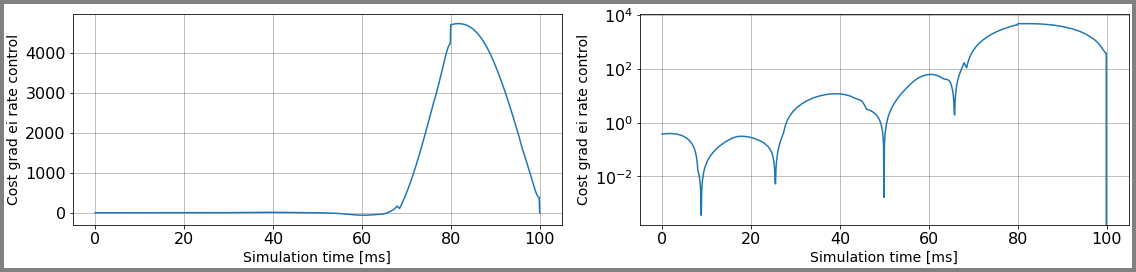

In [18]:
c_ = 4
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 6

set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  11.173162500000004  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5040140033937998 0.5245835868291204
Problem in initial value trasfer:  Vmean_exc -75.28436672061706 -75.28691315268688


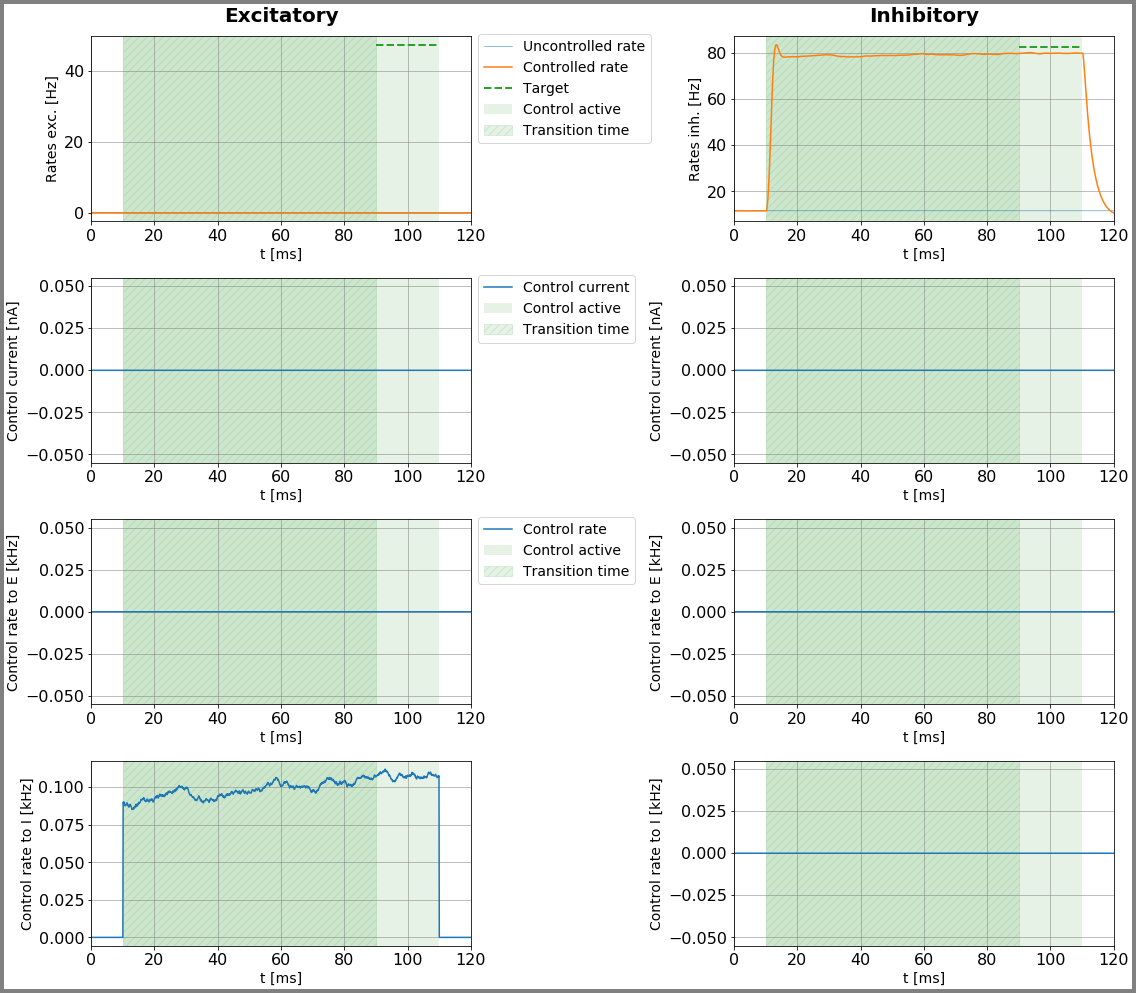

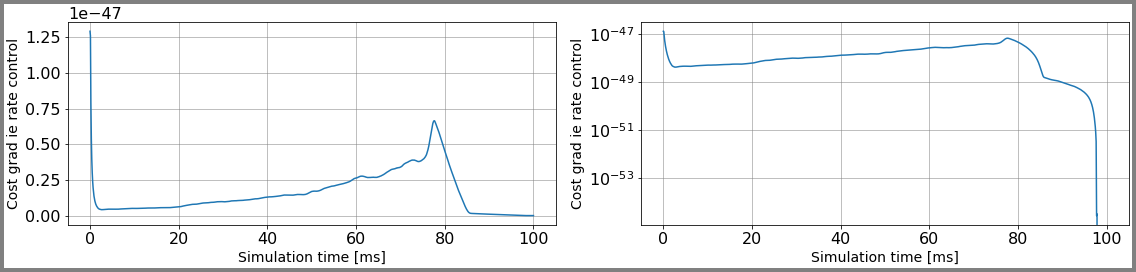

In [5]:
c_ = 5
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22702.281006457342
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
RUN  2 , total integrated cost =  22493.205225769263
RUN  3 , total integrated cost =  22492.184065981408
RUN  4 , total integrated cost =  22492.177371560465
RUN  5 , total integrated cost =  22492.17672661437
RUN  6 , total integrated cost =  22492.176719237006
RUN  7 , total integrated cost =  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


22492.176719139563
RUN  8 , total integrated cost =  22492.176719139563
Control only changes marginally.
RUN  8 , total integrated cost =  22492.176719139563
Improved over  8  iterations in  0.26862549999999885  seconds by  0.9254765512682184  percent.
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.382311323526517
Problem in initial value trasfer:  Vmean_exc -56.29824218663594 -56.298369490351355


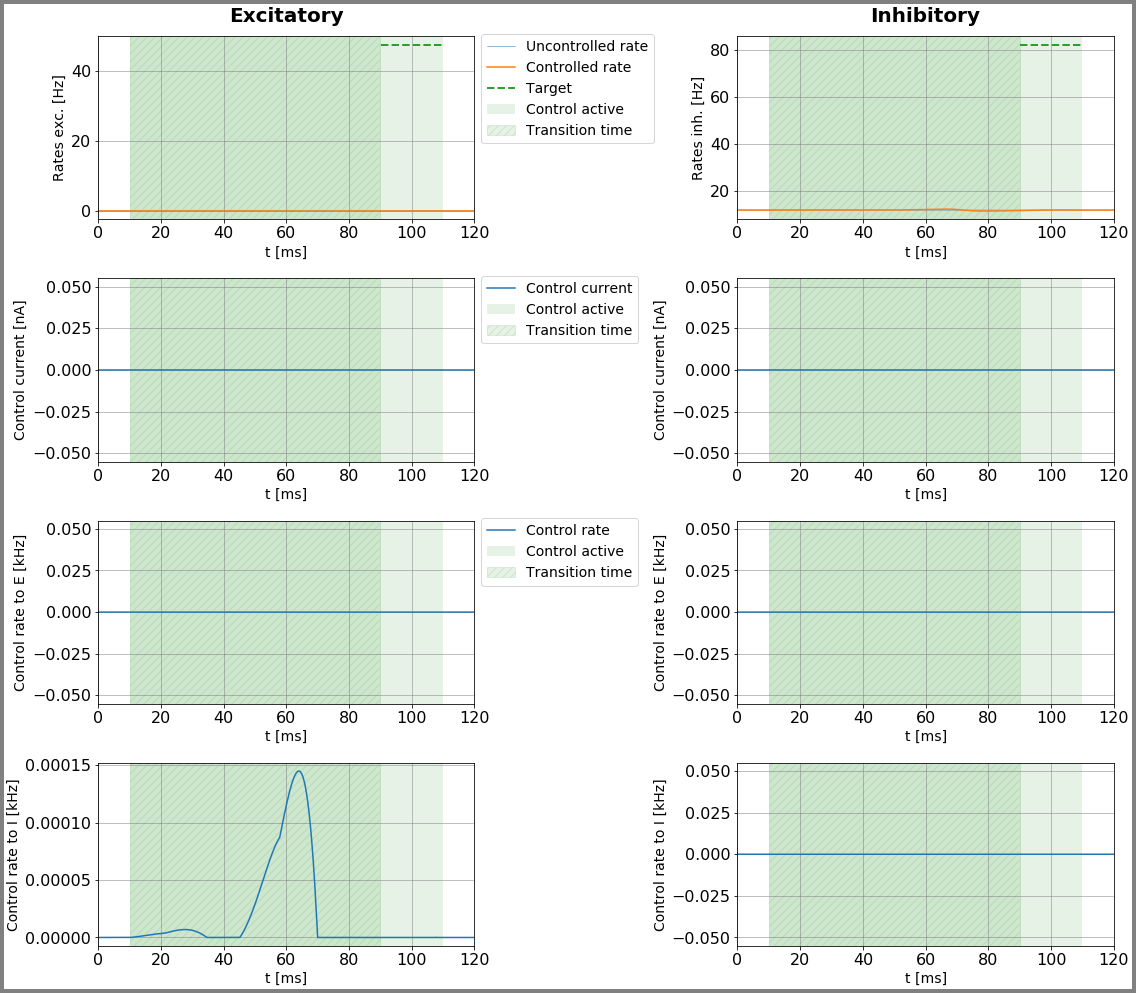

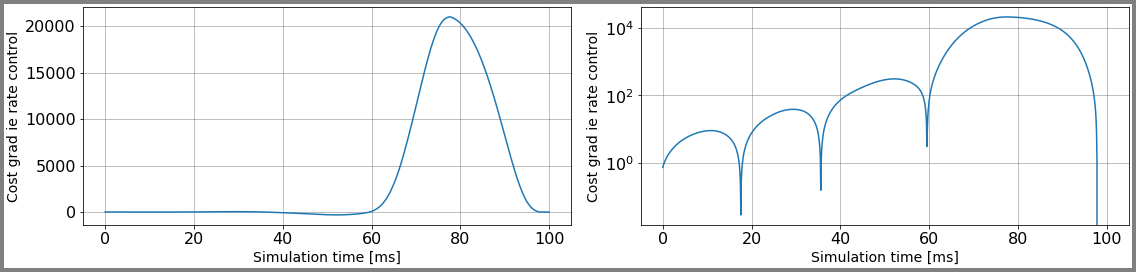

In [6]:
c_ = 5
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 7

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.09162978622223779
Gradient descend method:  None
RUN  1 , total integrated cost =  3.7281279875324647e-13
RUN  2 , total integrated cost =  3.117591889427703e-13
RUN  3 , total integrated cost =  2.1408817536270363e-13
RUN  4 , total integrated cost =  1.1461635096996523e-13
RUN  5 , total integrated cost =  3.20185969414259e-14
RUN  6 , total integrated cost =  1.4368016776808278e-14
RUN  7 , total integrated cost =  1.4355826121999152e-14
RUN  8 , total integrated cost =  1.4326753595590894e-14
RUN  9 , total integrated cost =  1.4283439915505123e-14
RUN  10 , total integrated cost =  1.3967902595163115e-14
RUN  11 , total integrated cost =  1.3829561086968513e-14
RUN  12 , total integrated cost =  1.2790425683216518e-14
RUN  13 , total integrated cost =  1.2679204926032699e-14
RUN  14 , total integrated cost =  1.2663232692940479e-14
RUN  15 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  243 , total integrated cost =  1.216199481028145e-14
Improved over  243  iterations in  6.157268299999998  seconds by  99.99999999998673  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5236309419822073
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.489136801837856
Problem in initial value trasfer:  sigmai_f 0.5015917391789261 0.5016180644331516
Problem in initial value trasfer:  Vmean_exc -56.174595340046594 -56.17460632842213
Problem in initial value trasfer:  tau_inh 0.5111015966885848 0.5111032769630236


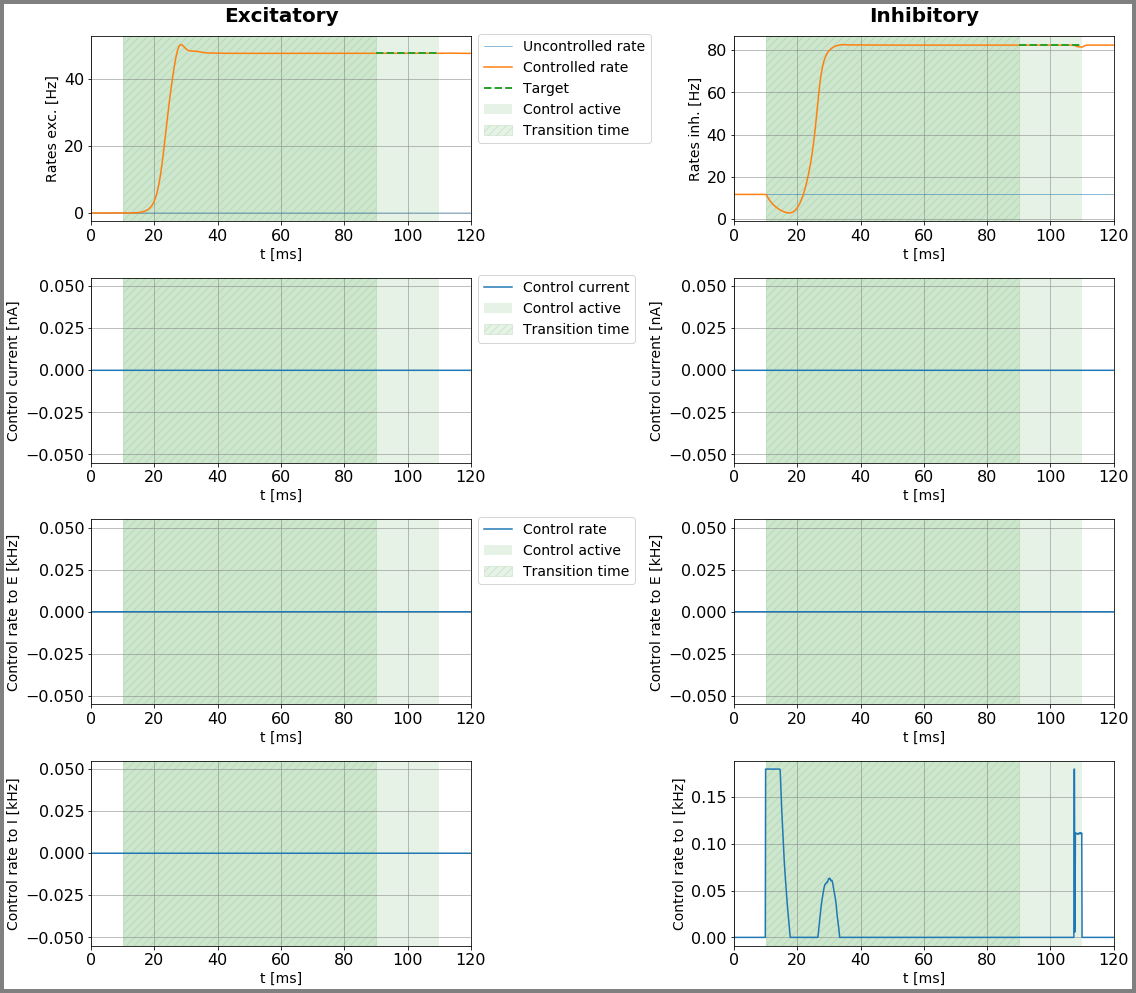

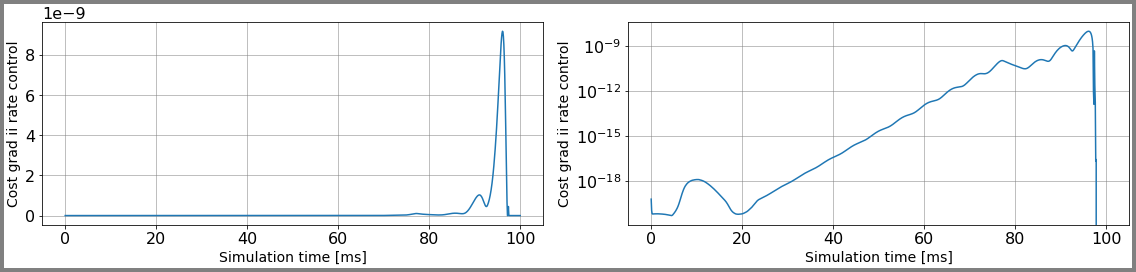

In [7]:
c_ = 6
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.327389740553391
Gradient descend method:  None
RUN  1 , total integrated cost =  2.327389740553391
Control only changes marginally.
RUN  1 , total integrated cost =  2.327389740553391
Improved over  1  iterations in  0.06262379999998302  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5530793536481136
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.385636805088781
Problem in initial value trasfer:  Vmean_exc -56.17459097372278 -56.17459098558247


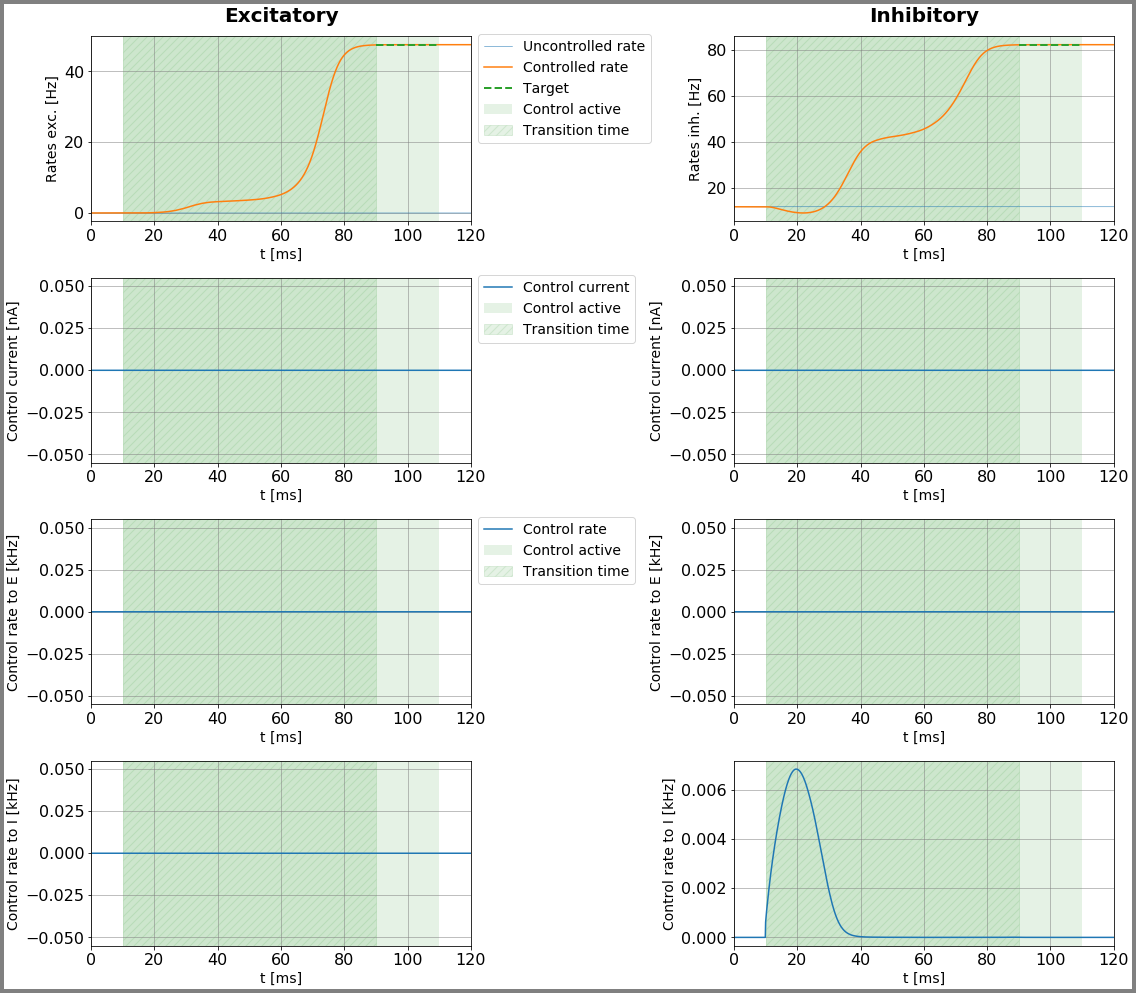

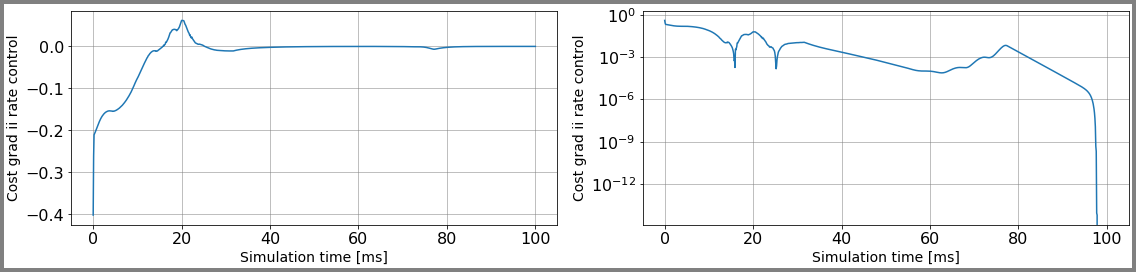

In [9]:
c_ = 6
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 8

In [ ]:
c_ = 7
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.6099170724206684
Gradient descend method:  None
RUN  1 , total integrated cost =  0.609917066497274
RUN  2 , total integrated cost =  0.6099170575888406
RUN  3 , total integrated cost =  0.6099170517611295
RUN  4 , total integrated cost =  0.6099170428644756
RUN  5 , total integrated cost =  0.6099170371292455
RUN  6 , total integrated cost =  0.6099170282476275
RUN  7 , total integrated cost =  0.6099170226046585
RUN  8 , total integrated cost =  0.6099170137374047
RUN  9 , total integrated cost =  0.6099170081860037
RUN  10 , total integrated cost =  0.609916999333076
RUN  11 , total integrated cost =  0.6099169938676999
RUN  12 , total integrated cost =  0.6099169860103084
RUN  13 , total integrated cost =  0.6099169806934187
RUN  14 , total integrated cost =  0.6099169727515766
RUN  15 , total integrated cost =  0.6099169675061598
RUN  16 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  313 , total integrated cost =  0.6099150523809403
Improved over  313  iterations in  37.73770030000003  seconds by  0.0003311990792553843  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144662805671914
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.105852187245137


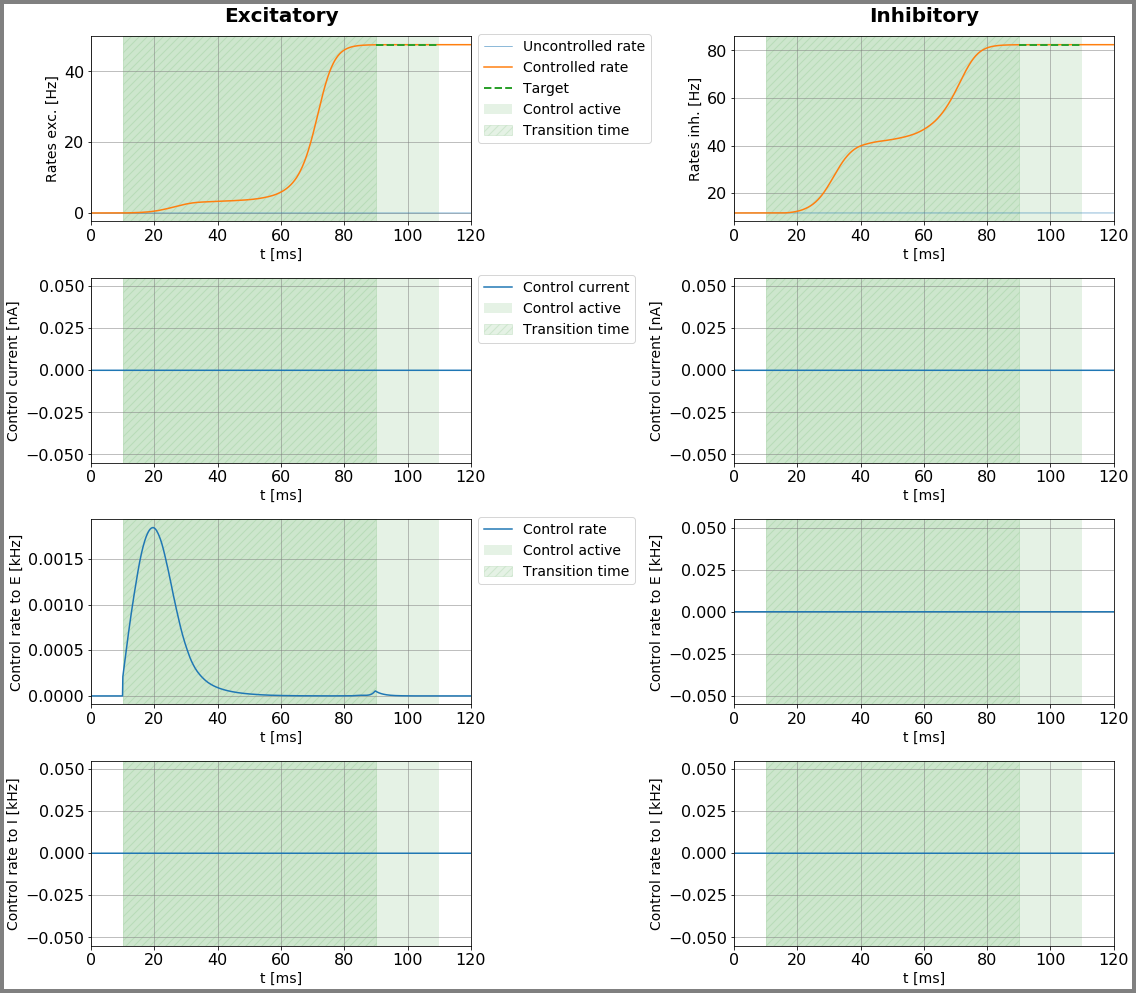

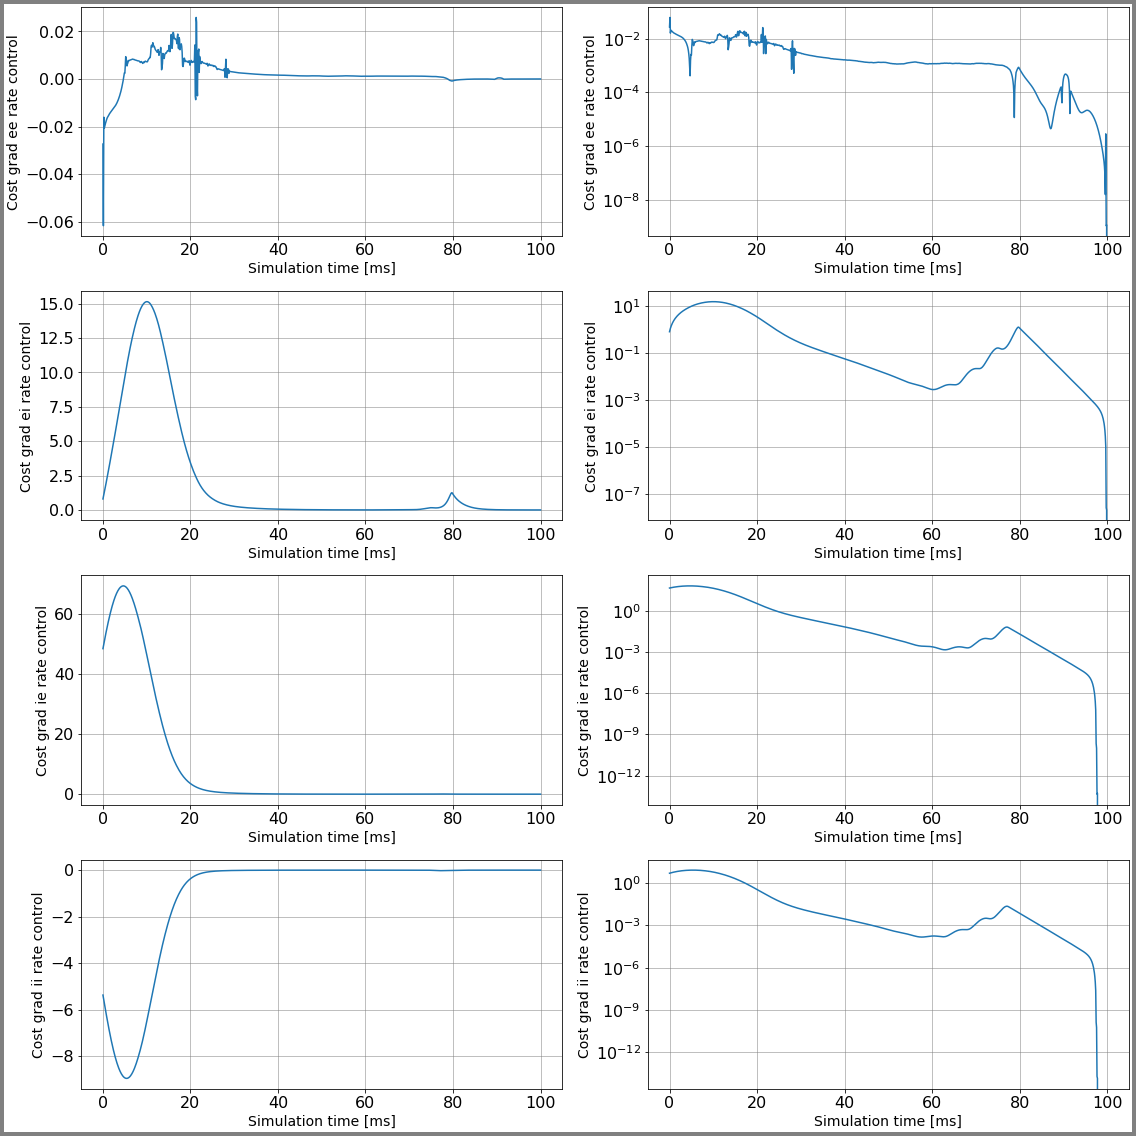

In [13]:
c_ = 7
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [14]:
print("cost a")
for i in range(len(costa)):
    j = int(len(costa[i]) - 1)
    while costa[i][j] == 0.:
        j = int(j-1)
    print(costa[i][j])

print("cost b")
for i in range(len(costb)):
    j = int(len(costb[i]) - 1)
    while costb[i][j] == 0.:
        j = int(j-1)
    print(costb[i][j])

cost a


IndexError: list index out of range